In [1]:
import os
os.chdir('../../../../..')

In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap
import seaborn as sns
from loguru import logger
from sklearn.manifold import TSNE, MDS
import gc
import logging
import time
from typing import Any, Dict, List, Sequence, Tuple
from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np
import polars as pl
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm


# =============================================================================
# MAIN EXPERIMENT
# =============================================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.covariance import oas

# Ensure third-party geometry frameworks are installed in the active environment:
# pip install pot ripser persim dscribe
import ot  # Python Optimal Transport (POT)
import persim
from dscribe.kernels import REMatchKernel
from ripser import ripser
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, REMatch, PersistentHomology
from src.helper_functions import create_chemiscope_viewer


In [3]:
qm9 = QM9Dataset(limit=25_000, descriptors=["soap"])
df = qm9.load()

2026-06-06 08:38:21.623 | INFO     | src.datasets:_load_full_qm9_df:846 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-06 08:38:22.030 | INFO     | src.datasets:_sample_qm9_df:1029 - QM9 sampling complete: strategy=stratified, requested_limit=25000, returned_rows=25000, sampling on columns=['num_atoms', 'gap'].
2026-06-06 08:38:22.031 | INFO     | src.datasets:_add_requested_descriptors:204 - Applying requested QM9 descriptors to sampled dataframe (rows=25000).
2026-06-06 08:38:22.057 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-06 08:38:46.616 | SUCCESS  | src.datasets:add_soap:1222 - Added SOAP embeddings and matrices.
2026-06-06 08:38:46.619 | INFO     | src.datasets:_add_requested_descriptors:215 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-06 08:38:46.623 | INFO     | src.datasets:_load_with_descriptor_filter:886 - QM9 descriptor null-filtering 

In [14]:
def get_global_soap_dim(df: pl.DataFrame, soap_matrix_col: str) -> int:
    """
    Determines the global SOAP feature dimensionality D by taking the
    maximum D observed across all molecules. Molecules with smaller D
    (fewer atom species present locally) will be zero-padded to this size.
    """
    dims = [np.array(mat).shape[1] for mat in df[soap_matrix_col].to_list()]
    D_max = int(np.max(dims))
    D_min = int(np.min(dims))
    if D_max != D_min:
        print(
            f"[Warning] SOAP feature dimension varies across molecules: "
            f"min={D_min}, max={D_max}. "
            f"All molecules will be padded to D={D_max}."
        )
    else:
        print(f"[OK] Consistent SOAP feature dimension: D={D_max}")
    return D_max


def project_to_grassmann(
    X_atomic: np.ndarray,
    k: int,
    D_global: int,
) -> np.ndarray:
    """
    Projects a per-atom feature matrix X_atomic of shape [n_atoms, D_local]
    onto the Grassmann manifold G(k, D_global).

    Two sources of shape inconsistency are handled:
      1. D_local < D_global: the feature matrix is zero-padded along the
         feature axis before SVD so all molecules live in the same space.
      2. n_atoms < k: fewer singular vectors than k are available; the
         basis matrix is zero-padded along the subspace axis.

    Returns a flat vector of length D_global * k.
    """
    n_atoms, D_local = X_atomic.shape

    # --- fix 1: pad feature dimension to D_global ---
    if D_local < D_global:
        pad = np.zeros((n_atoms, D_global - D_local))
        X_atomic = np.concatenate([X_atomic, pad], axis=1)
    elif D_local > D_global:
        # should not happen if D_global was computed as the max,
        # but guard against it anyway
        X_atomic = X_atomic[:, :D_global]

    # X_atomic is now [n_atoms, D_global]
    _, _, Vt = np.linalg.svd(X_atomic, full_matrices=False)
    n_available = Vt.shape[0]   # min(n_atoms, D_global)

    # --- fix 2: pad subspace dimension to k ---
    if n_available >= k:
        Y = Vt[:k, :].T                                          # [D_global, k]
    else:
        Y_available = Vt.T                                       # [D_global, n_available]
        padding     = np.zeros((D_global, k - n_available))
        Y           = np.concatenate([Y_available, padding], axis=1)  # [D_global, k]

    assert Y.shape == (D_global, k), (
        f"Expected ({D_global}, {k}), got {Y.shape}"
    )
    return Y.flatten()          # [D_global * k]


def build_grassmann_features(
    df: pl.DataFrame,
    soap_matrix_col: str,
    k: int,
    D_global: int,
) -> np.ndarray:
    """
    Builds a molecule-level feature matrix by projecting each molecule's
    per-atom SOAP matrix onto G(k, D_global).
    Returns shape [n_molecules, D_global * k].
    """
    features = []
    for mat in df[soap_matrix_col].to_list():
        arr = np.array(mat)
        features.append(project_to_grassmann(arr, k=k, D_global=D_global))
    X = np.vstack(features)
    assert X.shape == (len(features), D_global * k), (
        f"Expected ({len(features)}, {D_global * k}), got {X.shape}"
    )
    return X


def compute_explained_variance_profile(
    df: pl.DataFrame,
    soap_matrix_col: str,
    k_max: int = 20,
    D_global: int | None = None,
) -> pl.DataFrame:
    """
    Computes the mean cumulative explained variance ratio across all
    molecules as a function of k. Molecules with fewer atoms than k_max
    are padded with 1.0. Molecules with D_local < D_global are zero-padded
    before SVD so all singular value spectra are comparable.
    """
    if D_global is None:
        D_global = get_global_soap_dim(df, soap_matrix_col)

    all_ratios = []

    for mat in df[soap_matrix_col].to_list():
        arr = np.array(mat)
        n_atoms, D_local = arr.shape

        # pad feature dimension if needed
        if D_local < D_global:
            pad = np.zeros((n_atoms, D_global - D_local))
            arr = np.concatenate([arr, pad], axis=1)

        _, s, _ = np.linalg.svd(arr, full_matrices=False)
        s_sq  = s ** 2
        total = s_sq.sum()
        cumvar_raw = np.cumsum(s_sq) / total    # length: min(n_atoms, D_global)

        n_singular = len(cumvar_raw)
        if n_singular >= k_max:
            cumvar = cumvar_raw[:k_max]
        else:
            padding = np.ones(k_max - n_singular)
            cumvar  = np.concatenate([cumvar_raw, padding])

        all_ratios.append(cumvar)

    ratios_matrix = np.vstack(all_ratios)
    return pl.DataFrame({
        "k":           list(range(1, k_max + 1)),
        "mean_cumvar": ratios_matrix.mean(axis=0).tolist(),
        "std_cumvar":  ratios_matrix.std(axis=0).tolist(),
    })


def sweep_grassmann_k(
    df: pl.DataFrame,
    soap_matrix_col: str,
    property_col: str,
    k_values: list[int],
    n_splits: int = 5,
) -> pl.DataFrame:
    """
    Sweeps over a range of subspace dimensions k and records regression
    performance for each. D_global is computed once and reused across
    all k values so every feature matrix lives in the same ambient space.
    """
    D_global = get_global_soap_dim(df, soap_matrix_col)
    y = df[property_col].to_numpy()
    results = []

    for k in tqdm(k_values, desc="Grassmann k sweep"):
        X = build_grassmann_features(df, soap_matrix_col, k=k, D_global=D_global)
        mae_mean, mae_std, r2_mean = evaluate_grassmann_k(
            X, y, n_splits=n_splits, label=f"k={k}"
        )
        results.append({
            "k":        k,
            "Mean MAE": round(mae_mean, 4),
            "Std MAE":  round(mae_std,  4),
            "Mean R²":  round(r2_mean,  4),
        })
        print(f"  k={k:>3d}  MAE: {mae_mean:.4f} ± {mae_std:.4f}   R²: {r2_mean:.4f}")

    return pl.DataFrame(results)


def run_grassmann_justification(
    df: pl.DataFrame,
    soap_matrix_col: str,
    property_col: str,
    k_values: list[int] | None = None,
    k_max_variance: int = 20,
    n_splits: int = 5,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Runs both the explained variance profile and the regression sweep.
    D_global is computed once at the top level and passed through to
    all sub-functions so the ambient space is consistent everywhere.
    """
    if k_values is None:
        k_values = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]

    D_global = get_global_soap_dim(df, soap_matrix_col)

    print("=" * 60)
    print("Step 1: Computing explained variance profile")
    print("=" * 60)
    variance_df = compute_explained_variance_profile(
        df, soap_matrix_col, k_max=k_max_variance, D_global=D_global
    )
    print(variance_df)

    print("\n" + "=" * 60)
    print("Step 2: Regression performance sweep over k")
    print("=" * 60)
    regression_df = sweep_grassmann_k(
        df, soap_matrix_col, property_col,
        k_values=k_values, n_splits=n_splits,
    )
    print(regression_df)

    return variance_df, regression_df




In [11]:
isomer_subset = df.filter(pl.col("formula") == "C7H10O2")
variance_df, regression_df = run_grassmann_justification(
    isomer_subset,
    soap_matrix_col="soap_matrix",
    property_col="mu",
)

[OK] Consistent SOAP feature dimension: D=252
Step 1: Computing explained variance profile
shape: (20, 3)
┌─────┬─────────────┬────────────┐
│ k   ┆ mean_cumvar ┆ std_cumvar │
│ --- ┆ ---         ┆ ---        │
│ i64 ┆ f64         ┆ f64        │
╞═════╪═════════════╪════════════╡
│ 1   ┆ 0.889206    ┆ 0.017586   │
│ 2   ┆ 0.950748    ┆ 0.017657   │
│ 3   ┆ 0.97476     ┆ 0.01034    │
│ 4   ┆ 0.986116    ┆ 0.006745   │
│ 5   ┆ 0.991057    ┆ 0.004369   │
│ …   ┆ …           ┆ …          │
│ 16  ┆ 0.999864    ┆ 0.000085   │
│ 17  ┆ 0.99993     ┆ 0.000047   │
│ 18  ┆ 0.999974    ┆ 0.000019   │
│ 19  ┆ 1.0         ┆ 2.4532e-16 │
│ 20  ┆ 1.0         ┆ 0.0        │
└─────┴─────────────┴────────────┘

Step 2: Regression performance sweep over k
[OK] Consistent SOAP feature dimension: D=252


Grassmann k sweep:  10%|█         | 1/10 [00:00<00:05,  1.75it/s]

  k=  1  MAE: 0.6726 ± 0.0235   R²: 0.3480


Grassmann k sweep:  20%|██        | 2/10 [00:01<00:06,  1.28it/s]

  k=  2  MAE: 0.6890 ± 0.0335   R²: 0.3248


...

  k= 10  MAE: 0.8012 ± 0.0309   R²: 0.0617


Grassmann k sweep:  90%|█████████ | 9/10 [00:15<00:02,  2.25s/it]

  k= 15  MAE: 0.8223 ± 0.0364   R²: 0.0133


Grassmann k sweep: 100%|██████████| 10/10 [00:18<00:00,  1.89s/it]

  k= 20  MAE: 0.8312 ± 0.0337   R²: -0.0041
shape: (10, 4)
┌─────┬──────────┬─────────┬─────────┐
│ k   ┆ Mean MAE ┆ Std MAE ┆ Mean R² │
│ --- ┆ ---      ┆ ---     ┆ ---     │
│ i64 ┆ f64      ┆ f64     ┆ f64     │
╞═════╪══════════╪═════════╪═════════╡
│ 1   ┆ 0.6726   ┆ 0.0235  ┆ 0.348   │
│ 2   ┆ 0.689    ┆ 0.0335  ┆ 0.3248  │
│ 3   ┆ 0.6984   ┆ 0.0354  ┆ 0.3112  │
│ 4   ┆ 0.7381   ┆ 0.032   ┆ 0.2239  │
│ 5   ┆ 0.7491   ┆ 0.0399  ┆ 0.1983  │
│ 6   ┆ 0.7532   ┆ 0.0377  ┆ 0.1858  │
│ 8   ┆ 0.789    ┆ 0.0296  ┆ 0.098   │
│ 10  ┆ 0.8012   ┆ 0.0309  ┆ 0.0617  │
│ 15  ┆ 0.8223   ┆ 0.0364  ┆ 0.0133  │
│ 20  ┆ 0.8312   ┆ 0.0337  ┆ -0.0041 │
└─────┴──────────┴─────────┴─────────┘


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl


def plot_grassmann_justification(
    variance_df: pl.DataFrame,
    regression_df: pl.DataFrame,
    save_path: str | None = None,
) -> None:
    """Produces a publication-quality two-panel figure justifying the Grassmann

    subspace dimension selection for a thesis or journal article.
    """
    # ------------------------------------------------------------------
    # MATPLOTLIB STYLE SETUP (Publication Quality)
    # ------------------------------------------------------------------
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
            "mathtext.fontset": "cm",
            "axes.labelsize": 10,
            "axes.titlesize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8.5,
            "figure.titlesize": 12,
            "axes.edgecolor": "#333333",
            "axes.linewidth": 0.8,
        }
    )

    # Cohesive Academic Palette
    COLOR_VAR = "#1f77b4"  # Muted Indigo
    COLOR_R2 = "#2ca02c"  # Deep Teal
    COLOR_MAE = "#d62728"  # Coral Red
    COLOR_MUTED = "#555555"  # Neutral Dark Grey

    # Extract Data
    k_var = variance_df["k"].to_numpy()
    mean_c = variance_df["mean_cumvar"].to_numpy()
    std_c = variance_df["std_cumvar"].to_numpy()

    k_reg = regression_df["k"].to_numpy()
    r2 = regression_df["Mean R²"].to_numpy()
    mae = regression_df["Mean MAE"].to_numpy()
    mae_std = regression_df["Std MAE"].to_numpy()

    # Calculations
    threshold = 0.95
    k_95_candidates = k_var[mean_c >= threshold]
    k_95 = int(k_95_candidates[0]) if len(k_95_candidates) > 0 else None
    k_best_r2 = int(k_reg[np.argmax(r2)])

    # Figure Setup: 1 column wide (~6.5 inches is standard for single/double text width)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(6.8, 3.2),
        sharex=True,
    )

    # ------------------------------------------------------------------
    # LEFT PANEL: Cumulative Explained Variance
    # ------------------------------------------------------------------
    ax0 = axes[0]

    # Variance variance band and line
    ax0.fill_between(
        k_var,
        mean_c - std_c,
        mean_c + std_c,
        alpha=0.15,
        color=COLOR_VAR,
        label=r"$\mu \pm \sigma$ dispersion",
    )
    ax0.plot(
        k_var,
        mean_c,
        color=COLOR_VAR,
        linewidth=1.5,
        marker="o",
        markersize=3.5,
        label="Mean cum. variance",
        zorder=3,
    )

    # Threshold guidelines
    ax0.axhline(
        threshold,
        color=COLOR_MUTED,
        linewidth=0.8,
        linestyle="--",
        alpha=0.7,
        label="95% Threshold",
    )

    if k_95 is not None:
        ax0.axvline(
            k_95,
            color=COLOR_MUTED,
            linewidth=0.8,
            linestyle=":",
            alpha=0.8,
            label=f"Threshold selection ($k={k_95}$)",
        )

    # Formatting Left Panel
    ax0.set_xlabel("Subspace dimension $k$")
    ax0.set_ylabel("Cumulative explained variance")
    ax0.set_title("Variance Profile", fontweight="bold", pad=8)
    ax0.set_xlim(k_var.min() - 0.2, k_var.max() + 0.2)
    ax0.set_ylim(0.4, 1.03)  # Magnify the area of interest instead of starting at 0
    ax0.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
    ax0.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

    # Clean Spines
    ax0.spines["top"].set_visible(False)
    ax0.spines["right"].set_visible(False)

    # ------------------------------------------------------------------
    # RIGHT PANEL: Regression Performance (Dual Axis Resolved)
    # ------------------------------------------------------------------
    ax1 = axes[1]

    # R² Primary Axis
    (line1,) = ax1.plot(
        k_reg,
        r2,
        color=COLOR_R2,
        linewidth=1.5,
        marker="s",
        markersize=3.5,
        label="Mean $R^2$ (left)",
        zorder=3,
    )
    ax1.set_ylabel("$R^2$ score", color=COLOR_R2)
    ax1.tick_params(axis="y", labelcolor=COLOR_R2)

    # MAE Secondary Axis
    ax2 = ax1.twinx()
    (line2,) = ax2.plot(
        k_reg,
        mae,
        color=COLOR_MAE,
        linewidth=1.5,
        marker="^",
        markersize=3.5,
        linestyle="-.",
        label="Mean MAE (right)",
        zorder=3,
    )
    ax2.fill_between(
        k_reg,
        mae - mae_std,
        mae + mae_std,
        alpha=0.1,
        color=COLOR_MAE,
    )
    ax2.set_ylabel("Mean Absolute Error", color=COLOR_MAE)
    ax2.tick_params(axis="y", labelcolor=COLOR_MAE)

    # Add back the context of k_95 selection onto regression performance
    if k_95 is not None:
        ax1.axvline(
            k_95,
            color=COLOR_MUTED,
            linewidth=0.8,
            linestyle=":",
            alpha=0.8,
            zorder=1,
        )
        # Clean top-axis indicator instead of messy arrows
        ax1.text(
            k_95 + 0.1,
            ax1.get_ylim()[0] + 0.05,
            f"$k_{{var}}={k_95}$",
            color=COLOR_MUTED,
            fontsize=8,
            rotation=90,
        )

    # Formatting Right Panel
    ax1.set_xlabel("Subspace dimension $k$")
    ax1.set_title("Predictive Utility", fontweight="bold", pad=8)

    # CRITICAL: Grid only on primary to prevent secondary clash
    ax1.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)

    # Combined Legend without border clutter
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(
        lines,
        labels,
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="none",
    )

    # Clean Spines for Twinned Layout
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    # Enforce precise integer ticks for k
    for ax in [ax0, ax1]:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Layout adjustment (Using tight_layout with explicit rect for suptitle)
    plt.tight_layout()

    if save_path is not None:
        # Vector format (.pdf or .svg) is mandatory for LaTeX/Thesis print layouts
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[+] Publication figure saved to {save_path}")

    plt.show()

[+] Publication figure saved to /Users/karlfindhansen/Desktop/thesis figures/grassmann/grassmann_k_justification.png


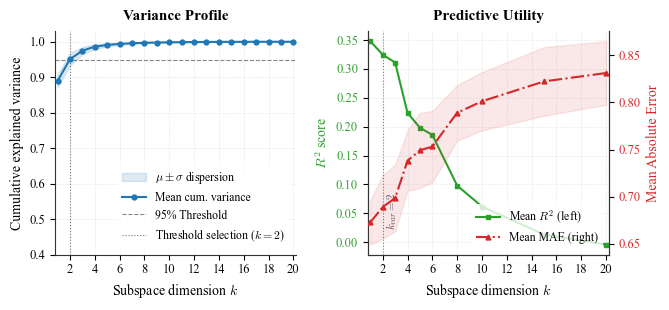

In [20]:
plot_grassmann_justification(
    variance_df,
    regression_df,
    save_path="/Users/karlfindhansen/Desktop/thesis figures/grassmann/grassmann_k_justification.png",
)